# REINFORCE on CartPole-v1

This notebook implements the vanilla REINFORCE algorithm and a value-baseline variant on **CartPole-v1**. It runs two ablation studies and exports three academic-style figures as **vector PDF** files:

- **Fig 1**: High variance of vanilla REINFORCE (5 random seeds: raw curves + smoothed mean)
- **Fig 2**: Convergence comparison with / without a value baseline (mean ± 1 std)
- **Fig 3**: Policy entropy evolution during training (mean ± 1 std)

The code is compatible with both **gymnasium** and **gym** APIs.

In [1]:
# If needed, uncomment one of the following lines:
# !pip install gymnasium[classic-control]
# !pip install gym==0.26.2

In [2]:
from pathlib import Path
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

try:
    import gymnasium as gym
    GYM_BACKEND = 'gymnasium'
except ImportError:
    import gym
    GYM_BACKEND = 'gym'

print(f'Using backend: {GYM_BACKEND}')
print(f'PyTorch version: {torch.__version__}')

Using backend: gymnasium
PyTorch version: 2.9.0+cu126


In [3]:
# -----------------------------
# Global configuration
# -----------------------------
ENV_NAME = 'CartPole-v1'
SEEDS = [0, 1, 2, 3, 4]
NUM_EPISODES = 500
GAMMA = 0.99
POLICY_LR = 1e-2
VALUE_LR = 5e-3   # Lower than policy LR as required
HIDDEN_DIM = 128
SMOOTH_WINDOW = 20
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Academic color palette
BLUE = '#2166AC'
RED = '#D6604D'
GREEN = '#4DAC26'
GRAY = '#808080'

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

print(f'Device: {DEVICE}')

Device: cuda


In [4]:
# -----------------------------
# Utility functions
# -----------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def reset_env(env, seed=None):
    if seed is not None:
        try:
            out = env.reset(seed=seed)
        except TypeError:
            if hasattr(env, 'seed'):
                env.seed(seed)
            out = env.reset()
    else:
        out = env.reset()

    if isinstance(out, tuple):
        state = out[0]
    else:
        state = out
    return np.asarray(state, dtype=np.float32)


def step_env(env, action):
    out = env.step(action)
    if len(out) == 5:
        next_state, reward, terminated, truncated, info = out
        done = terminated or truncated
    else:
        next_state, reward, done, info = out
    return np.asarray(next_state, dtype=np.float32), float(reward), bool(done), info


def discounted_returns(rewards, gamma):
    returns = []
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.append(G)
    returns.reverse()
    return torch.tensor(returns, dtype=torch.float32, device=DEVICE)


def moving_average(x, window=20):
    x = np.asarray(x, dtype=np.float64)
    if window <= 1:
        return x.copy()
    out = np.empty_like(x, dtype=np.float64)
    for i in range(len(x)):
        start = max(0, i - window + 1)
        out[i] = x[start:i+1].mean()
    return out


def style_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', linewidth=0.8, color='0.85')
    ax.set_axisbelow(True)

In [5]:
# -----------------------------
# Networks
# -----------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        logits = self.net(x)
        return Categorical(logits=logits)


class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

In [6]:
# -----------------------------
# REINFORCE training
# -----------------------------
def train_reinforce(
    env_name='CartPole-v1',
    seed=0,
    num_episodes=500,
    gamma=0.99,
    policy_lr=1e-2,
    use_baseline=False,
    value_lr=5e-3,
    hidden_dim=128,
):
    set_seed(seed)

    env = gym.make(env_name)
    if hasattr(env.action_space, 'seed'):
        try:
            env.action_space.seed(seed)
        except Exception:
            pass

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(state_dim, action_dim, hidden_dim).to(DEVICE)
    policy_optim = torch.optim.Adam(policy.parameters(), lr=policy_lr)

    value_net = None
    value_optim = None
    if use_baseline:
        value_net = ValueNetwork(state_dim, hidden_dim).to(DEVICE)
        value_optim = torch.optim.Adam(value_net.parameters(), lr=value_lr)

    episode_returns = []
    episode_entropies = []

    for episode in range(num_episodes):
        state = reset_env(env, seed=seed if episode == 0 else None)
        done = False

        states = []
        log_probs = []
        rewards = []
        entropies = []

        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            dist = policy(state_tensor)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            entropy = dist.entropy()

            next_state, reward, done, _ = step_env(env, action.item())

            states.append(state)
            log_probs.append(log_prob.squeeze(0))
            rewards.append(reward)
            entropies.append(entropy.item())

            state = next_state

        returns = discounted_returns(rewards, gamma)
        log_probs_tensor = torch.stack(log_probs)

        policy_optim.zero_grad()

        if use_baseline:
            state_tensor = torch.tensor(np.asarray(states), dtype=torch.float32, device=DEVICE)
            values = value_net(state_tensor)
            advantages = returns - values.detach()
            policy_loss = -(log_probs_tensor * advantages).sum()

            value_optim.zero_grad()
            value_loss = F.mse_loss(values, returns)
            value_loss.backward()
            torch.nn.utils.clip_grad_norm_(value_net.parameters(), 1.0)
            value_optim.step()
        else:
            # Vanilla REINFORCE: use the raw discounted returns G_t directly.
            policy_loss = -(log_probs_tensor * returns).sum()

        policy_loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        policy_optim.step()

        episode_returns.append(float(np.sum(rewards)))
        episode_entropies.append(float(np.mean(entropies)))

    env.close()
    return {
        'returns': np.asarray(episode_returns, dtype=np.float32),
        'entropies': np.asarray(episode_entropies, dtype=np.float32),
    }

In [7]:
# -----------------------------
# Multi-seed experiment runner
# -----------------------------
def run_multi_seed_experiment(use_baseline=False):
    all_returns = []
    all_entropies = []

    variant_name = 'REINFORCE + Value Baseline' if use_baseline else 'Vanilla REINFORCE'
    print(f'Running {variant_name}')

    for seed in SEEDS:
        result = train_reinforce(
            env_name=ENV_NAME,
            seed=seed,
            num_episodes=NUM_EPISODES,
            gamma=GAMMA,
            policy_lr=POLICY_LR,
            use_baseline=use_baseline,
            value_lr=VALUE_LR,
            hidden_dim=HIDDEN_DIM,
        )
        all_returns.append(result['returns'])
        all_entropies.append(result['entropies'])
        print(
            f'  Seed {seed:>2d} | Final-20 Return Mean: '
            f"{result['returns'][-20:].mean():.2f}"
        )

    return {
        'returns': np.stack(all_returns, axis=0),
        'entropies': np.stack(all_entropies, axis=0),
    }

In [8]:
# Run the two ablations
vanilla_results = run_multi_seed_experiment(use_baseline=False)
baseline_results = run_multi_seed_experiment(use_baseline=True)

Running Vanilla REINFORCE
  Seed  0 | Final-20 Return Mean: 9.10
  Seed  1 | Final-20 Return Mean: 9.35
  Seed  2 | Final-20 Return Mean: 9.45
  Seed  3 | Final-20 Return Mean: 9.15
  Seed  4 | Final-20 Return Mean: 9.15
Running REINFORCE + Value Baseline
  Seed  0 | Final-20 Return Mean: 9.10
  Seed  1 | Final-20 Return Mean: 9.35
  Seed  2 | Final-20 Return Mean: 500.00
  Seed  3 | Final-20 Return Mean: 355.25
  Seed  4 | Final-20 Return Mean: 9.15


In [15]:
# -----------------------------
# Plotting helpers
# -----------------------------
def plot_mean_std(ax, data, color, label, window=20, clip_lower=None, clip_upper=None):
    """
    Plot smoothed mean ± 1 standard deviation.

    clip_lower / clip_upper only clip the shaded uncertainty band,
    not the mean curve itself.
    """
    smoothed = np.vstack([moving_average(run, window) for run in data])
    mean = smoothed.mean(axis=0)
    std = smoothed.std(axis=0)

    x = np.arange(1, len(mean) + 1)
    lower = mean - std
    upper = mean + std

    if clip_lower is not None:
        lower = np.maximum(lower, clip_lower)
    if clip_upper is not None:
        upper = np.minimum(upper, clip_upper)

    ax.plot(x, mean, color=color, linewidth=2.2, label=label, zorder=3)
    ax.fill_between(x, lower, upper, color=color, alpha=0.18, linewidth=0, zorder=2)

    return mean, std

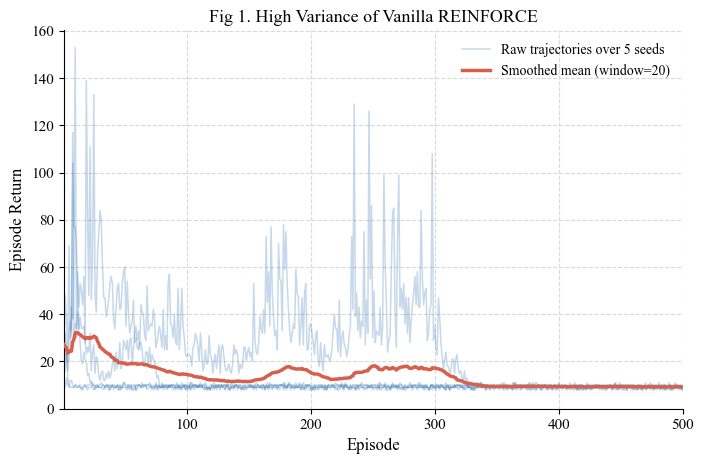

In [16]:
# -----------------------------
# Fig 1: High variance of vanilla REINFORCE
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))
episodes = np.arange(1, NUM_EPISODES + 1)

raw_returns = vanilla_results['returns']

for idx, seed in enumerate(SEEDS):
    ax.plot(
        episodes,
        raw_returns[idx],
        color=BLUE,
        alpha=0.25,
        linewidth=1.1,
        label='Raw trajectories over 5 seeds' if idx == 0 else None,
        zorder=1,
    )

smoothed_mean = moving_average(raw_returns.mean(axis=0), window=SMOOTH_WINDOW)

ax.plot(
    episodes,
    smoothed_mean,
    color=RED,
    linewidth=2.5,
    label=f'Smoothed mean (window={SMOOTH_WINDOW})',
    zorder=3,
)

style_axes(ax)
ax.set_title('Fig 1. High Variance of Vanilla REINFORCE')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Return')
ax.set_xlim(1, NUM_EPISODES)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
fig1_path = FIG_DIR / 'fig1_reinforce_high_variance.pdf'
fig.savefig(fig1_path, format='pdf', bbox_inches='tight')
plt.show()

print(f'Saved: {fig1_path.resolve()}')

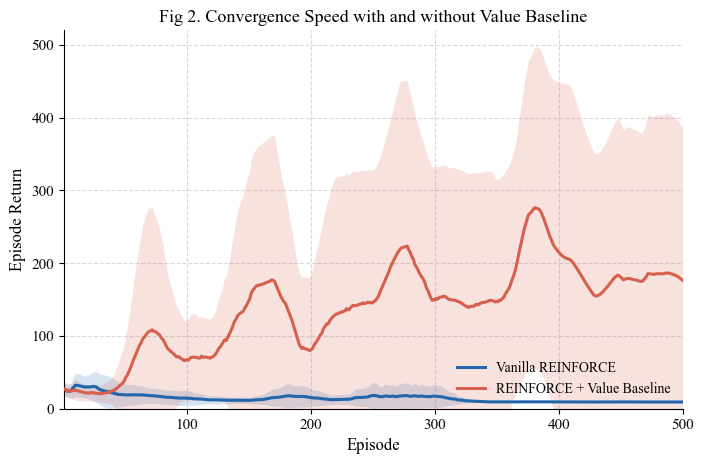

In [17]:
# -----------------------------
# Fig 2: Convergence comparison with / without value baseline
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))

plot_mean_std(
    ax,
    vanilla_results['returns'],
    color=BLUE,
    label='Vanilla REINFORCE',
    window=SMOOTH_WINDOW,
    clip_lower=0,
    clip_upper=500,
)

plot_mean_std(
    ax,
    baseline_results['returns'],
    color=RED,
    label='REINFORCE + Value Baseline',
    window=SMOOTH_WINDOW,
    clip_lower=0,
    clip_upper=500,
)

style_axes(ax)
ax.set_title('Fig 2. Convergence Speed with and without Value Baseline')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode Return')
ax.set_xlim(1, NUM_EPISODES)
ax.set_ylim(0, 520)
ax.legend(frameon=False, loc='lower right')

fig.tight_layout()
fig2_path = FIG_DIR / 'fig2_convergence_baseline_comparison.pdf'
fig.savefig(fig2_path, format='pdf', bbox_inches='tight')
plt.show()

print(f'Saved: {fig2_path.resolve()}')

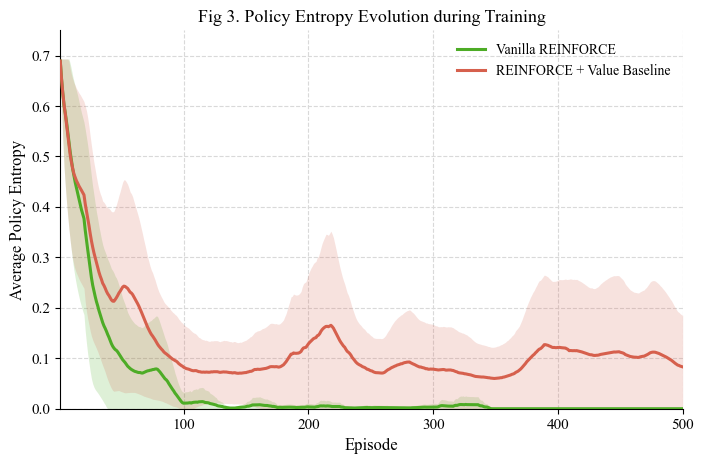

In [18]:
# -----------------------------
# Fig 3: Policy entropy evolution
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 4.8))

max_entropy = np.log(2)

plot_mean_std(
    ax,
    vanilla_results['entropies'],
    color=GREEN,
    label='Vanilla REINFORCE',
    window=SMOOTH_WINDOW,
    clip_lower=0,
    clip_upper=max_entropy,
)

plot_mean_std(
    ax,
    baseline_results['entropies'],
    color=RED,
    label='REINFORCE + Value Baseline',
    window=SMOOTH_WINDOW,
    clip_lower=0,
    clip_upper=max_entropy,
)

style_axes(ax)
ax.set_title('Fig 3. Policy Entropy Evolution during Training')
ax.set_xlabel('Episode')
ax.set_ylabel('Average Policy Entropy')
ax.set_xlim(1, NUM_EPISODES)
ax.set_ylim(0, 0.75)
ax.legend(frameon=False, loc='upper right')

fig.tight_layout()
fig3_path = FIG_DIR / 'fig3_policy_entropy_evolution.pdf'
fig.savefig(fig3_path, format='pdf', bbox_inches='tight')
plt.show()

print(f'Saved: {fig3_path.resolve()}')

In [14]:
# -----------------------------
# Optional quick summary
# -----------------------------
def summarize_final_performance(name, returns):
    final20 = returns[:, -20:].mean(axis=1)
    print(
        f'{name:<30s} | Final-20 mean across seeds: '
        f'{final20.mean():.2f} ± {final20.std():.2f}'
    )

summarize_final_performance('Vanilla REINFORCE', vanilla_results['returns'])
summarize_final_performance('REINFORCE + Value Baseline', baseline_results['returns'])

print('Generated figure files:')
for path in [fig1_path, fig2_path, fig3_path]:
    print(' -', path.resolve())